# 04 - Pengujian End-to-End Sistem per Format Input

Notebook ini menguji **pipeline lengkap** sistem peringkasan rapat secara end-to-end:

```
Input File → Transkripsi (Whisper) → Filter Kata Kasar → Peringkasan (IndoT5) → Evaluasi ROUGE
```

Pengujian dipisahkan berdasarkan **format input** (MP4, MP3, WAV) untuk membandingkan:
1. **Waktu proses** di setiap tahap pipeline
2. **Skor ROUGE** hasil ringkasan per format
3. **Konsistensi output** antar format input

In [ ]:
import os
os.chdir('..')
print("Current working dir:", os.getcwd())

import pandas as pd
from pathlib import Path

# List dokumen segmen yang mau diambil
NAMA_DOKUMEN = [
    'Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg01',
    'Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg02',
    'Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg03',
    'Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg01',
    'Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg02',
    'Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg03',
    'Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg04',
    'Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg05',
    'Uji_Paripurna_Ke_20_Persidangan_IV_2024_2025_seg01',
    'Uji_Paripurna_Ke_20_Persidangan_IV_2024_2025_seg02',
    'Uji_Paripurna_Ke_20_Persidangan_IV_2024_2025_seg03'
]

# Load dataset
df = pd.read_csv('dataset/data_segment_corrected_ocr.csv', sep=';')

# Filter hanya dokumen yang diinginkan
df_dok = df[df['dokumen_asal'].isin(NAMA_DOKUMEN)].copy()

# Handle missing value
df_dok['target_summary_manual'] = df_dok['target_summary_manual'].fillna('').astype(str)

# Ambil hanya kolom yang dibutuhkan (per segmen, tidak digabung)
df_e2e_ref = df_dok[['dokumen_asal', 'target_summary_manual']].copy()

# Rename kolom agar sesuai format evaluasi
df_e2e_ref = df_e2e_ref.rename(columns={
    'target_summary_manual': 'referensi_ringkasan'
})

df_e2e_ref['jumlah_segmen'] = 1
df_e2e_ref = df_e2e_ref.sort_values(by='dokumen_asal').reset_index(drop=True)

# Simpan ke CSV
out_path = Path('dataset/end_to_end_test_reference.csv')
df_e2e_ref.to_csv(out_path, index=False, encoding='utf-8')

# Output
print(f"Total data referensi: {len(df_e2e_ref)} segmen")
display(df_e2e_ref)

Current working dir: d:\Skripsi\meeting-summarizer
Total data referensi: 11 segmen


,dokumen_asal,referensi_ringkasan,jumlah_segmen
0,Uji_Paripurna_Ke_20_Persidangan_IV_2024_2025_s...,Rapat Paripurna DPR RI membuka Masa Persidanga...,1
1,Uji_Paripurna_Ke_20_Persidangan_IV_2024_2025_s...,DPR RI melanjutkan pembahasan delapan rancanga...,1
2,Uji_Paripurna_Ke_20_Persidangan_IV_2024_2025_s...,"DPR RI mencermati kebijakan pendapatan, belanj...",1
3,Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg01,Rapat Paripurna DPR RI menyambut Parlemen Rema...,1
4,Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg02,Rapat Paripurna DPR RI membuka Masa Persidanga...,1
5,Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg03,DPR RI bersama pemerintah memiliki komitmen un...,1
6,Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg01,Rapat Paripurna DPR RI menetapkan agenda sidan...,1
7,Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg02,Rapat Paripurna DPR RI membahas Putusan Mahkam...,1
8,Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg03,Anggota DPR RI menyampaikan klarifikasi terkai...,1
9,Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg04,Rapat Paripurna DPR RI membahas KUHAP baru yan...,1


## 1. Import & Setup

In [2]:
import os
import sys
import time
import pandas as pd
import evaluate
import torch
import matplotlib.pyplot as plt
from pathlib import Path

ffmpeg_dir = r"C:\Users\User\AppData\Local\Microsoft\WinGet\Packages"
for root, dirs, files in os.walk(ffmpeg_dir):
    if "ffmpeg.exe" in files:
        os.environ["PATH"] = root + ";" + os.environ["PATH"]
        print(f"FFmpeg ditemukan: {root}")
        break

sys.path.append('..')
from modules.transcriber import transcribe_audio, WHISPER_MODEL, WHISPER_LANGUAGE
from modules.filter_kata import filter_teks
from modules.summarizer import summarize_text

print(f"Whisper model: {WHISPER_MODEL}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

d:\Skripsi\meeting-summarizer\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FFmpeg ditemukan: C:\Users\User\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-8.0.1-full_build\bin
Whisper model: medium
Device: cpu


## 2. Konfigurasi File Uji

Menggunakan file referensi khusus end-to-end (`end_to_end_test_reference.csv`) yang berisi ringkasan target (ground truth).

In [3]:
df_ref = pd.read_csv('dataset/end_to_end_test_reference.csv')

SAMPLE_FILES = ['Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg01',
                'Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg02',
                'Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg03',
                'Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg01',
                'Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg02',
                'Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg03',
                'Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg04',
                'Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg05',
                'Uji_Paripurna_Ke_20_Persidangan_IV_2024_2025_seg01',
                'Uji_Paripurna_Ke_20_Persidangan_IV_2024_2025_seg02',
                'Uji_Paripurna_Ke_20_Persidangan_IV_2024_2025_seg03'
] 

print(f"Referensi end-to-end di CSV: {len(df_ref)} dokumen")
print(f"SEDANG MENGUJI {len(SAMPLE_FILES)} FILE")

# Filter tabel untuk ditampilin
df_tampil = df_ref[df_ref['dokumen_asal'].isin(SAMPLE_FILES)]
display(df_tampil[['dokumen_asal', 'jumlah_segmen']])

# Direktori sumber
DIR_MP4 = Path('dataset/01_raw/video_mp4')
DIR_MP3 = Path('dataset/01_raw/audio_mp3')
DIR_WAV = Path('dataset/01_raw/audio_wav')

# Format dan direktori
FORMAT_MAP = {
    'MP4': (DIR_MP4, '.mp4'),
    'MP3': (DIR_MP3, '.mp3'),
    'WAV': (DIR_WAV, '.wav'),
}

# Validasi keberadaan file
print("\nValidasi file uji:")
for name in SAMPLE_FILES:
    for fmt, (dir_path, ext) in FORMAT_MAP.items():
        fp = dir_path / (name + ext)
        status = '✅' if fp.exists() else '❌'
        print(f"  {status} {fmt}: {fp.name}")

Referensi end-to-end di CSV: 11 dokumen
SEDANG MENGUJI 11 FILE


,dokumen_asal,jumlah_segmen
0,Uji_Paripurna_Ke_20_Persidangan_IV_2024_2025_s...,1
1,Uji_Paripurna_Ke_20_Persidangan_IV_2024_2025_s...,1
2,Uji_Paripurna_Ke_20_Persidangan_IV_2024_2025_s...,1
3,Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg01,1
4,Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg02,1
5,Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg03,1
6,Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg01,1
7,Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg02,1
8,Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg03,1
9,Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg04,1



Validasi file uji:
  ✅ MP4: Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg01.mp4
  ✅ MP3: Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg01.mp3
  ✅ WAV: Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg01.wav
  ✅ MP4: Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg02.mp4
  ✅ MP3: Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg02.mp3
  ✅ WAV: Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg02.wav
  ✅ MP4: Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg03.mp4
  ✅ MP3: Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg03.mp3
  ✅ WAV: Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg03.wav
  ✅ MP4: Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg01.mp4
  ✅ MP3: Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg01.mp3
  ✅ WAV: Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg01.wav
  ✅ MP4: Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg02.mp4
  ✅ MP3: Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg02.mp3
  ✅ WAV: Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg02.wav
  ✅ MP4: Uji_Paripurna_Ke_8_Persida

## 3. Fungsi Pipeline End-to-End

Menjalankan seluruh tahapan dan mencatat waktu per tahap.

In [4]:
import subprocess
import json as _json

def get_durasi_detik(file_path):
    """Dapatkan durasi file audio/video menggunakan ffprobe."""
    try:
        result = subprocess.run(
            ['ffprobe', '-v', 'quiet', '-print_format', 'json',
             '-show_format', str(file_path)],
            capture_output=True, text=True, timeout=30
        )
        info = _json.loads(result.stdout)
        return round(float(info['format']['duration']), 2)
    except Exception:
        return 0.0

def pipeline_end_to_end(file_path: Path, fmt_label: str) -> dict:
    """
    Jalankan pipeline lengkap untuk satu file:
      1. Transkripsi (Whisper)
      2. Filter kata kasar
      3. Peringkasan (IndoT5)
    """
    hasil = {
        'file': file_path.stem,
        'format': fmt_label,
    }
    hasil['durasi_detik'] = get_durasi_detik(file_path)
    
    # ── Tahap 1: Transkripsi Whisper ──
    print(f"Tahap 1: Transkripsi Whisper...")
    t0 = time.time()
    teks_transkrip = transcribe_audio(
        file_path,
        model_name=WHISPER_MODEL,
        language=WHISPER_LANGUAGE,
    )
    hasil['waktu_transkripsi'] = round(time.time() - t0, 2)
    hasil['jumlah_kata_transkrip'] = len(teks_transkrip.split())
    print(f"      {hasil['waktu_transkripsi']}s | {hasil['jumlah_kata_transkrip']} kata")
    
    # ── Tahap 2: Filter Kata Kasar ──
    print(f"Tahap 2: Filter kata kasar...")
    t0 = time.time()
    teks_bersih = filter_teks(teks_transkrip, hapus=True)
    hasil['waktu_filter'] = round(time.time() - t0, 4)
    hasil['jumlah_kata_bersih'] = len(teks_bersih.split())
    kata_difilter = hasil['jumlah_kata_transkrip'] - hasil['jumlah_kata_bersih']
    print(f"      {hasil['waktu_filter']}s | {kata_difilter} kata difilter")
    
    # ── Tahap 3: Peringkasan IndoT5 ──
    print(f"Tahap 3: Peringkasan IndoT5...")
    t0 = time.time()
    ringkasan = summarize_text(teks_bersih)
    hasil['waktu_ringkasan'] = round(time.time() - t0, 2)
    hasil['jumlah_kata_ringkasan'] = len(ringkasan.split())
    print(f"      {hasil['waktu_ringkasan']}s | {hasil['jumlah_kata_ringkasan']} kata ringkasan")
    
    # ── Total ──
    hasil['waktu_total'] = round(
        hasil['waktu_transkripsi'] + hasil['waktu_filter'] + hasil['waktu_ringkasan'], 2
    )
    hasil['teks_transkrip'] = teks_transkrip
    hasil['teks_bersih'] = teks_bersih
    hasil['ringkasan'] = ringkasan
    
    return hasil

print("Fungsi pipeline_end_to_end siap.")

Fungsi pipeline_end_to_end siap.


## 4. Pengujian End-to-End

Pipeline dijalankan untuk setiap file uji × setiap format input.

In [5]:
semua_hasil = []

total_tes = len(SAMPLE_FILES) * len(FORMAT_MAP)
counter = 0

for name in SAMPLE_FILES:
    print(f"\n{'='*60}")
    print(f"FILE: {name}")
    print(f"{'='*60}")
    
    for fmt_label, (dir_path, ext) in FORMAT_MAP.items():
        counter += 1
        file_path = dir_path / (name + ext)
        
        if not file_path.exists():
            print(f"\n  [{counter}/{total_tes}] {fmt_label}: File tidak ditemukan, SKIP")
            continue
        
        print(f"\n  [{counter}/{total_tes}] Format: {fmt_label}")
        
        try:
            hasil = pipeline_end_to_end(file_path, fmt_label)
            semua_hasil.append(hasil)
            print(f"    Total Waktu: {hasil['waktu_total']}s")
        except Exception as e:
            print(f"    ERROR: {e}")

print(f"\n\n{'='*60}")
print(f"Selesai! {len(semua_hasil)}/{total_tes} pengujian berhasil.")
print(f"{'='*60}")


FILE: Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg01

  [1/33] Format: MP4
Tahap 1: Transkripsi Whisper...


d:\Skripsi\meeting-summarizer\venv\Lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")
100%|██████████| 24699/24699 [03:05<00:00, 133.18frames/s]


      194.24s | 340 kata
Tahap 2: Filter kata kasar...
      0.0005s | 0 kata difilter
Tahap 3: Peringkasan IndoT5...


Loading weights: 100%|██████████| 284/284 [00:00<00:00, 494.40it/s, Materializing param=shared.weight]                                                       
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


      9.83s | 50 kata ringkasan
    Total Waktu: 204.07s

  [2/33] Format: MP3
Tahap 1: Transkripsi Whisper...


...

      193.03s | 397 kata
Tahap 2: Filter kata kasar...
      0.0006s | 0 kata difilter
Tahap 3: Peringkasan IndoT5...
      5.03s | 36 kata ringkasan
    Total Waktu: 198.06s

  [32/33] Format: MP3
Tahap 1: Transkripsi Whisper...


100%|██████████| 24901/24901 [03:13<00:00, 128.38frames/s]


      194.22s | 399 kata
Tahap 2: Filter kata kasar...
      0.0004s | 0 kata difilter
Tahap 3: Peringkasan IndoT5...
      11.2s | 75 kata ringkasan
    Total Waktu: 205.42s

  [33/33] Format: WAV
Tahap 1: Transkripsi Whisper...


100%|██████████| 24901/24901 [03:12<00:00, 129.22frames/s]


      192.87s | 397 kata
Tahap 2: Filter kata kasar...
      0.0006s | 0 kata difilter
Tahap 3: Peringkasan IndoT5...
      4.97s | 36 kata ringkasan
    Total Waktu: 197.84s


Selesai! 33/33 pengujian berhasil.


In [6]:
for h in semua_hasil:
    print(f"FORMAT: {h['format']}")
    print(f"RINGKASAN: {h['ringkasan']}")
    print(f"TEKS BERSIH (input summarizer): {h['teks_bersih'][:200]}")
    print()

FORMAT: MP4
RINGKASAN: . Anggota DPR RI menyampaikan aspirasi untuk melakukan pemilihan anggota baru, dengan tema tahun 2025 yang akan dilaksanakan pada 3 dan 5 November 2024. Pimpinan DPR RI juga menerima laporan dari Presiden Indonesia tentang pembentukan Ketua DPR RI. Rapat Paripurna telah memberikan keputusan kepada pimpinan DPR RI dalam rapat paripurna.
TEKS BERSIH (input summarizer): Sidang Dewan yang kami hormati pada Rapat Paripurna hari ini, telah hadir peserta Parlemen Remaja tahun 2025 di atas sana. Tukuh tangannya. Parlemen Remaja merupakan kegiatan tahunan DPR RI dalam rang

FORMAT: MP3
RINGKASAN: . Anggota DPR RI menyampaikan aspirasi untuk melakukan pelantikan anggota baru, yang akan dilaksanakan pada 3 sampai dengan 5 November 2025. Pimpinan DPR RI juga menerima laporan dari pemerintah dan pimpinan fraksi-fraksi. Rapat Paripurna telah memberikan keputusan tentang perubahan antar waktu.
TEKS BERSIH (input summarizer): Sidang Dewan yang kami hormati pada Rapat Paripurna h

## 5. Tabel Perbandingan Waktu per Tahap dan Format

In [ ]:
df_hasil = pd.DataFrame(semua_hasil)

# Tabel detail per file
kolom_tampil = ['file', 'format', 'durasi_detik', 'waktu_transkripsi', 'waktu_filter', 
                'waktu_ringkasan', 'waktu_total', 'jumlah_kata_transkrip',
                'jumlah_kata_bersih', 'jumlah_kata_ringkasan']
print("DETAIL HASIL PER FILE DAN FORMAT")
print("=" * 60)
display(df_hasil[kolom_tampil])

# Rata-rata waktu per format
print("\nRATA-RATA WAKTU PER FORMAT INPUT")
print("=" * 60)
df_avg = df_hasil.groupby('format')[[
    'waktu_transkripsi', 'waktu_filter', 'waktu_ringkasan', 'waktu_total'
]].mean().round(2)
display(df_avg)

# ROUGE per file dan per format
print("\nROUGE PER FILE DAN FORMAT")
print("=" * 60)
rouge = evaluate.load('rouge')
rouge_rows = []
for h in semua_hasil:
    file_name = h['file']
    ref_row = df_ref[df_ref['dokumen_asal'] == file_name]
    if len(ref_row) == 0:
        continue
    scores = rouge.compute(predictions=[h['ringkasan']], references=[ref_row.iloc[0]['referensi_ringkasan']])
    row = {
        'file': file_name,
        'format': h['format'],
        'rouge1': round(scores.get('rouge1', 0), 4),
        'rouge2': round(scores.get('rouge2', 0), 4),
        'rougeL': round(scores.get('rougeL', 0), 4),
        'rougeLsum': round(scores.get('rougeLsum', 0), 4)
    }
    rouge_rows.append(row)
df_rouge_per_file = pd.DataFrame(rouge_rows)
display(df_rouge_per_file)

print("\nRATA-RATA ROUGE PER FORMAT INPUT")
print("=" * 60)
df_rouge_per_format = df_rouge_per_file.groupby('format')[['rouge1', 'rouge2', 'rougeL', 'rougeLsum']].mean().round(4)
display(df_rouge_per_format)

DETAIL HASIL PER FILE DAN FORMAT


,file,format,durasi_detik,waktu_transkripsi,waktu_filter,waktu_ringkasan,waktu_total,jumlah_kata_transkrip,jumlah_kata_bersih,jumlah_kata_ringkasan
0,Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg01,MP4,246.99,194.24,0.0005,9.83,204.07,340,340,50
1,Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg01,MP3,246.99,176.33,0.0005,5.80,182.13,344,344,41
2,Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg01,WAV,246.99,178.15,0.0005,6.38,184.53,340,340,50
3,Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg02,MP4,226.00,165.94,0.0006,6.92,172.86,347,347,52
4,Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg02,MP3,226.00,165.59,0.0005,7.86,173.45,347,347,48
5,Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg02,WAV,226.00,164.68,0.0005,7.43,172.11,347,347,52
6,Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg03,MP4,228.00,168.92,0.0003,4.96,173.88,357,357,37
7,Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg03,MP3,228.00,166.97,0.0005,5.40,172.37,357,357,44
8,Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg03,WAV,228.00,161.13,0.0006,4.83,165.96,357,357,37
9,Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg01,MP4,197.02,155.39,0.0005,8.78,164.17,337,337,60



RATA-RATA WAKTU PER FORMAT INPUT


,waktu_transkripsi,waktu_filter,waktu_ringkasan,waktu_total
format,,,,
MP3,164.42,0.0,7.24,171.65
MP4,164.14,0.0,7.29,171.42
WAV,162.08,0.0,7.03,169.11



ROUGE PER FILE DAN FORMAT


,file,format,rouge1,rouge2,rougeL,rougeLsum
0,Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg01,MP4,0.5417,0.2553,0.3333,0.3333
1,Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg01,MP3,0.4318,0.2326,0.3182,0.3182
2,Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg01,WAV,0.5417,0.2553,0.3333,0.3333
3,Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg02,MP4,0.3704,0.1509,0.1852,0.1852
4,Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg02,MP3,0.3810,0.1553,0.2667,0.2667
5,Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg02,WAV,0.3704,0.1509,0.1852,0.1852
6,Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg03,MP4,0.4286,0.1463,0.2857,0.2857
7,Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg03,MP3,0.4667,0.1591,0.2444,0.2444
8,Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg03,WAV,0.4286,0.1463,0.2857,0.2857
9,Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg01,MP4,0.4536,0.3158,0.3505,0.3505



RATA-RATA ROUGE PER FORMAT INPUT


,rouge1,rouge2,rougeL,rougeLsum
format,,,,
MP3,0.4102,0.1963,0.2782,0.2782
MP4,0.4310,0.2020,0.2776,0.2776
WAV,0.4310,0.2020,0.2776,0.2776


## 6. Evaluasi ROUGE per Format Input

Membandingkan ringkasan pipeline end-to-end dengan referensi gabungan di `end_to_end_test_reference.csv`.

In [8]:
rouge = evaluate.load('rouge')

# Untuk setiap format, bandingkan ringkasan dengan referensi end-to-end
rouge_per_format = {}

for fmt_label in FORMAT_MAP.keys():
    hasil_fmt = [h for h in semua_hasil if h['format'] == fmt_label]
    if not hasil_fmt:
        continue
    
    preds_fmt = []
    refs_fmt = []
    
    for h in hasil_fmt:
        file_name = h['file']
        ref_row = df_ref[df_ref['dokumen_asal'] == file_name]
        
        if len(ref_row) > 0:
            preds_fmt.append(h['ringkasan'])
            refs_fmt.append(ref_row.iloc[0]['referensi_ringkasan'])
    
    if preds_fmt:
        scores = rouge.compute(predictions=preds_fmt, references=refs_fmt)
        rouge_per_format[fmt_label] = scores

# Tampilkan hasil ROUGE
print("SKOR ROUGE PER FORMAT INPUT")
print("=" * 60)

rouge_rows = []
for fmt, scores in rouge_per_format.items():
    row = {'Format': fmt}
    for metric, value in scores.items():
        row[metric] = round(value, 4)
    rouge_rows.append(row)

df_rouge = pd.DataFrame(rouge_rows)
display(df_rouge)

SKOR ROUGE PER FORMAT INPUT


,Format,rouge1,rouge2,rougeL,rougeLsum
0,MP4,0.4302,0.2023,0.2774,0.2771
1,MP3,0.4102,0.1957,0.2783,0.2768
2,WAV,0.4302,0.2023,0.2774,0.2771


## 7. Visualisasi Perbandingan

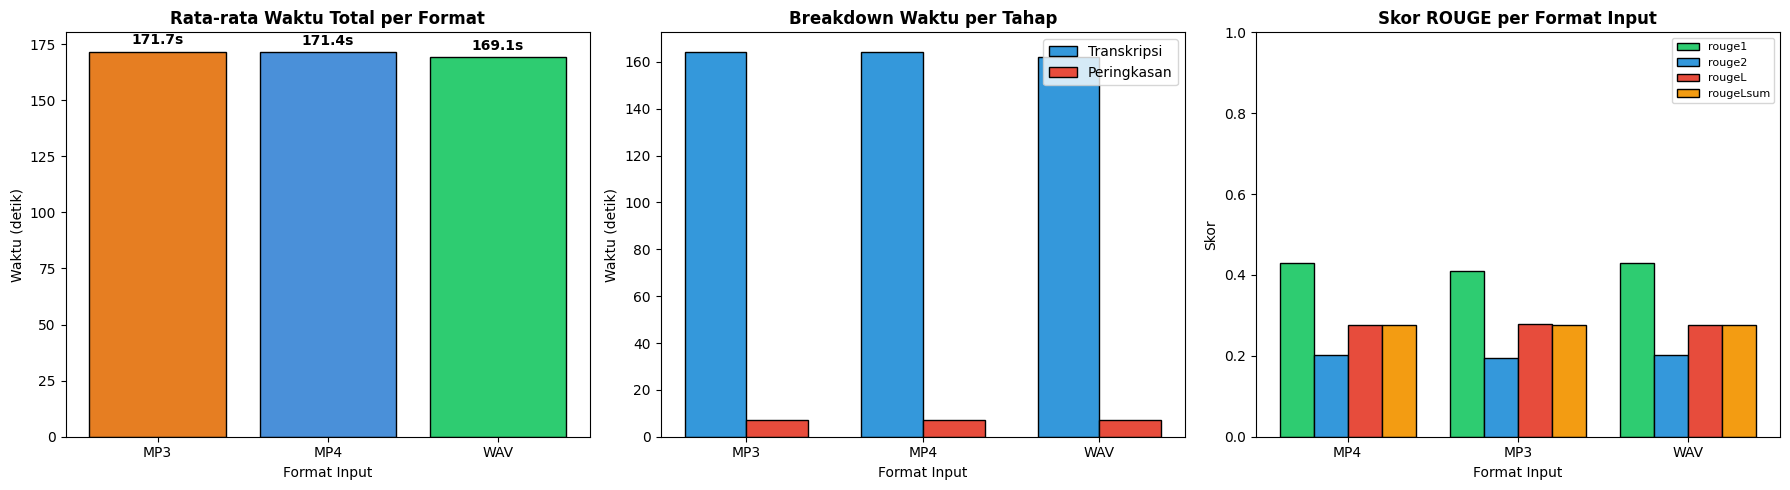

Grafik disimpan ke dataset/end_to_end_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {'MP4': '#4A90D9', 'MP3': '#E67E22', 'WAV': '#2ECC71'}

# ── Grafik 1: Rata-rata Waktu Total per Format ──
ax1 = axes[0]
avg_total = df_hasil.groupby('format')['waktu_total'].mean()
bars1 = ax1.bar(avg_total.index, avg_total.values, 
                color=[colors[f] for f in avg_total.index], edgecolor='black')
ax1.set_title('Rata-rata Waktu Total per Format', fontsize=12, fontweight='bold')
ax1.set_ylabel('Waktu (detik)')
ax1.set_xlabel('Format Input')
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.1f}s',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Grafik 2: Breakdown Waktu per Tahap ──
ax2 = axes[1]
tahap_cols = ['waktu_transkripsi', 'waktu_ringkasan']
df_breakdown = df_hasil.groupby('format')[tahap_cols].mean()

x_pos = range(len(df_breakdown.index))
width = 0.35
bars_t = ax2.bar([p - width/2 for p in x_pos], df_breakdown['waktu_transkripsi'], 
                  width, label='Transkripsi', color='#3498DB', edgecolor='black')
bars_s = ax2.bar([p + width/2 for p in x_pos], df_breakdown['waktu_ringkasan'],
                  width, label='Peringkasan', color='#E74C3C', edgecolor='black')
ax2.set_title('Breakdown Waktu per Tahap', fontsize=12, fontweight='bold')
ax2.set_ylabel('Waktu (detik)')
ax2.set_xlabel('Format Input')
ax2.set_xticks(list(x_pos))
ax2.set_xticklabels(df_breakdown.index)
ax2.legend()

# ── Grafik 3: Skor ROUGE per Format ──
ax3 = axes[2]
if len(df_rouge) > 0:
    rouge_metrics = [c for c in df_rouge.columns if c != 'Format']
    x_pos3 = range(len(df_rouge))
    n_metrics = len(rouge_metrics)
    w = 0.8 / n_metrics
    
    metric_colors = ['#2ECC71', '#3498DB', '#E74C3C', '#F39C12']
    for i, metric in enumerate(rouge_metrics):
        offset = (i - n_metrics/2 + 0.5) * w
        bars_r = ax3.bar([p + offset for p in x_pos3], df_rouge[metric],
                         w, label=metric, color=metric_colors[i % len(metric_colors)],
                         edgecolor='black')
    
    ax3.set_title('Skor ROUGE per Format Input', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Skor')
    ax3.set_xlabel('Format Input')
    ax3.set_xticks(list(x_pos3))
    ax3.set_xticklabels(df_rouge['Format'])
    ax3.legend(fontsize=8)
    ax3.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig('dataset/end_to_end_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan ke dataset/end_to_end_comparison.png")

## 8. Perbandingan Konsistensi Output Antar Format

Cek apakah hasil transkripsi dan ringkasan konsisten meskipun format input berbeda.

In [10]:
# Bandingkan konsistensi antar format untuk file yang sama
rouge_konsistensi = evaluate.load('rouge')

print("KONSISTENSI TRANSKRIPSI ANTAR FORMAT")
print("=" * 60)

for name in SAMPLE_FILES:
    hasil_file = {h['format']: h for h in semua_hasil if h['file'] == name}
    formats_tersedia = list(hasil_file.keys())
    
    if len(formats_tersedia) < 2:
        continue
    
    print(f"\nFile {name}:")
    
    # Bandingkan transkripsi WAV vs format lain (WAV sebagai baseline)
    if 'WAV' in hasil_file:
        baseline = hasil_file['WAV']['teks_transkrip']
        for fmt in ['MP4', 'MP3']:
            if fmt in hasil_file:
                other = hasil_file[fmt]['teks_transkrip']
                score = rouge_konsistensi.compute(
                    predictions=[other], references=[baseline]
                )
                print(f"  WAV vs {fmt} (transkripsi): "
                      f"ROUGE-1={score['rouge1']:.4f} | "
                      f"ROUGE-L={score['rougeL']:.4f}")
    
    # Bandingkan ringkasan
    if 'WAV' in hasil_file:
        baseline_ring = hasil_file['WAV']['ringkasan']
        for fmt in ['MP4', 'MP3']:
            if fmt in hasil_file:
                other_ring = hasil_file[fmt]['ringkasan']
                score_ring = rouge_konsistensi.compute(
                    predictions=[other_ring], references=[baseline_ring]
                )
                print(f"  WAV vs {fmt} (ringkasan) : "
                      f"ROUGE-1={score_ring['rouge1']:.4f} | "
                      f"ROUGE-L={score_ring['rougeL']:.4f}")

KONSISTENSI TRANSKRIPSI ANTAR FORMAT

File Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg01:
  WAV vs MP4 (transkripsi): ROUGE-1=1.0000 | ROUGE-L=1.0000
  WAV vs MP3 (transkripsi): ROUGE-1=0.9576 | ROUGE-L=0.9576
  WAV vs MP4 (ringkasan) : ROUGE-1=1.0000 | ROUGE-L=1.0000
  WAV vs MP3 (ringkasan) : ROUGE-1=0.7333 | ROUGE-L=0.6222

File Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg02:
  WAV vs MP4 (transkripsi): ROUGE-1=1.0000 | ROUGE-L=1.0000
  WAV vs MP3 (transkripsi): ROUGE-1=0.9972 | ROUGE-L=0.9972
  WAV vs MP4 (ringkasan) : ROUGE-1=1.0000 | ROUGE-L=1.0000
  WAV vs MP3 (ringkasan) : ROUGE-1=0.6990 | ROUGE-L=0.3883

File Uji_Paripurna_Ke_7_Persidangan_II_2025_2026_seg03:
  WAV vs MP4 (transkripsi): ROUGE-1=1.0000 | ROUGE-L=1.0000
  WAV vs MP3 (transkripsi): ROUGE-1=0.9807 | ROUGE-L=0.9807
  WAV vs MP4 (ringkasan) : ROUGE-1=1.0000 | ROUGE-L=1.0000
  WAV vs MP3 (ringkasan) : ROUGE-1=0.6341 | ROUGE-L=0.5854

File Uji_Paripurna_Ke_8_Persidangan_II_2025_2026_seg01:
  WAV vs MP4 (transkr

## 9. Ringkasan Hasil Pengujian

In [11]:
print("\n" + "=" * 60)
print("  RINGKASAN PENGUJIAN END-TO-END")
print("=" * 60)

print(f"\nJumlah file diuji  : {len(SAMPLE_FILES)}")
print(f"Format diuji       : {', '.join(FORMAT_MAP.keys())}")
print(f"Total pengujian    : {len(semua_hasil)}")

# Waktu rata-rata
print(f"\nRATA-RATA WAKTU (detik):")
print("-" * 50)
for fmt in FORMAT_MAP.keys():
    data_fmt = [h for h in semua_hasil if h['format'] == fmt]
    if data_fmt:
        avg_transkrip = sum(h['waktu_transkripsi'] for h in data_fmt) / len(data_fmt)
        avg_filter = sum(h['waktu_filter'] for h in data_fmt) / len(data_fmt)
        avg_ringkas = sum(h['waktu_ringkasan'] for h in data_fmt) / len(data_fmt)
        avg_total = sum(h['waktu_total'] for h in data_fmt) / len(data_fmt)
        print(f"  {fmt}: Transkripsi={avg_transkrip:.1f}s | "
              f"Filter={avg_filter:.4f}s | "
              f"Ringkasan={avg_ringkas:.1f}s | "
              f"Total={avg_total:.1f}s")

# ROUGE
print(f"\nSKOR ROUGE:")
print("-" * 50)
for fmt, scores in rouge_per_format.items():
    r1 = scores.get('rouge1', 0)
    r2 = scores.get('rouge2', 0)
    rl = scores.get('rougeL', 0)
    print(f"  {fmt}: ROUGE-1={r1:.4f} | ROUGE-2={r2:.4f} | ROUGE-L={rl:.4f}")

print(f"\n{'='*60}")
print("  Pipeline: Input → Whisper → Filter Kata → IndoT5 → Output")
print(f"{'='*60}")


  RINGKASAN PENGUJIAN END-TO-END

Jumlah file diuji  : 11
Format diuji       : MP4, MP3, WAV
Total pengujian    : 33

RATA-RATA WAKTU (detik):
--------------------------------------------------
  MP4: Transkripsi=164.1s | Filter=0.0005s | Ringkasan=7.3s | Total=171.4s
  MP3: Transkripsi=164.4s | Filter=0.0005s | Ringkasan=7.2s | Total=171.7s
  WAV: Transkripsi=162.1s | Filter=0.0005s | Ringkasan=7.0s | Total=169.1s

SKOR ROUGE:
--------------------------------------------------
  MP4: ROUGE-1=0.4302 | ROUGE-2=0.2023 | ROUGE-L=0.2774
  MP3: ROUGE-1=0.4102 | ROUGE-2=0.1957 | ROUGE-L=0.2783
  WAV: ROUGE-1=0.4302 | ROUGE-2=0.2023 | ROUGE-L=0.2774

  Pipeline: Input → Whisper → Filter Kata → IndoT5 → Output


## 10. Simpan Hasil ke CSV

In [12]:
# Simpan hasil detail
kolom_simpan = ['file', 'format', 'waktu_transkripsi', 'waktu_filter',
                'waktu_ringkasan', 'waktu_total', 'jumlah_kata_transkrip',
                'jumlah_kata_bersih', 'jumlah_kata_ringkasan',
                'teks_transkrip', 'teks_bersih', 'ringkasan']
df_simpan = df_hasil[kolom_simpan]
df_simpan.to_csv('dataset/hasil_end_to_end_test.csv', index=False, encoding='utf-8')

df_avg.to_csv('dataset/avg_waktu_per_format.csv', index=False, encoding='utf-8')

# Simpan skor ROUGE
if 'df_rouge_per_file' in globals():
    df_rouge_per_file.to_csv('dataset/rouge_per_file.csv', index=False, encoding='utf-8')
if 'df_rouge_per_format' in globals():
    df_rouge_per_format.to_csv('dataset/rouge_avg_per_format.csv', index=False, encoding='utf-8')

df_rouge.to_csv('dataset/rouge_per_format.csv', index=False, encoding='utf-8')

print("Hasil berhasil tersimpan!:")
print("  dataset/hasil_end_to_end_test.csv")
print("  dataset/avg_waktu_per_format.csv")
print("  dataset/rouge_per_file.csv")
print("  dataset/rouge_avg_per_format.csv")
print("  dataset/rouge_per_format.csv")
print("  dataset/end_to_end_comparison.png")

Hasil berhasil tersimpan!:
  dataset/hasil_end_to_end_test.csv
  dataset/avg_waktu_per_format.csv
  dataset/rouge_per_file.csv
  dataset/rouge_avg_per_format.csv
  dataset/rouge_per_format.csv
  dataset/end_to_end_comparison.png


In [13]:
# 1. Menyimpan data khusus waktu per file (termasuk durasi_detik)
kolom_waktu = ['file', 'format', 'durasi_detik', 'waktu_transkripsi', 'waktu_filter', 
               'waktu_ringkasan', 'waktu_total']
df_waktu_per_file = df_hasil[kolom_waktu]
df_waktu_per_file.to_csv('dataset/waktu_per_file.csv', index=False, encoding='utf-8')

# 2. Menyimpan ulang avg_waktu_per_format dengan kolom format
df_avg.reset_index().to_csv('dataset/avg_waktu_per_format.csv', index=False, encoding='utf-8')

# 3. (Opsional) Memperbarui hasil keseluruhan agar durasi_detik juga masuk
kolom_simpan_lengkap = ['file', 'format', 'durasi_detik', 'waktu_transkripsi', 'waktu_filter',
                'waktu_ringkasan', 'waktu_total', 'jumlah_kata_transkrip',
                'jumlah_kata_bersih', 'jumlah_kata_ringkasan',
                'teks_transkrip', 'teks_bersih', 'ringkasan']
df_hasil[kolom_simpan_lengkap].to_csv('dataset/hasil_end_to_end_test.csv', index=False, encoding='utf-8')

print("Berhasil menyimpan ulang CSV!")
print(" - dataset/waktu_per_file.csv")
print(" - dataset/avg_waktu_per_format.csv")


Berhasil menyimpan ulang CSV!
 - dataset/waktu_per_file.csv
 - dataset/avg_waktu_per_format.csv
